# DSA 5102 - Programming Assignment 1


## Description

As the first homework of this course, you will apply the knowledge you have learned in the first lecture on `linear models` and simple extensions using `kernel` methods on some datasets. This is also a chance to learn to use `jupyter notebook` and basic `sklearn` functionalities. A basic introduction to installing and using `jupyter notebooks` is found [here](https://www.datacamp.com/community/tutorials/tutorial-jupyter-notebook). You are strongly encouraged to use python 3 instead of python 2


The goals of this homework are
  * Learn basic data processing and machine learning using python
  * Reinforce knowledge on linear models and kernel methods
  * Prepare for the project in this course
  
Whenever you are stuck, you are encouraged to look at the jupyter notebook demonstration for the first lecture for some guidance. You should also learn to look at documentation of online libraries. For example, if you want to perform *kernel ridge regression* using `sklearn`, a quick google will land you on [this page](https://scikit-learn.org/stable/modules/kernel_ridge.html), where extensive description and examples are given.

## Instructions

Please complete each question below directly in this notebook. Note that you can write in the cells to describe what you are doing and any issues you face. If you are familiar, you can also format it using `markdown` as it is supported by `jupyter`. 

The grade given is based on the following
  1. Scientific correctness of your approach
  2. Clear documentation of your approach

## Dataset

We will work on the [Energy Efficiency dataset](https://archive.ics.uci.edu/dataset/242/energy%2Befficiency) from the UCI Machine Learning Repository. The data describe 768 simulated residential building configurations. For this assignment, the goal is to predict **heating load** from eight building design properties:

1. `Relative_Compactness`
2. `Surface_Area`
3. `Wall_Area`
4. `Roof_Area`
5. `Overall_Height`
6. `Orientation`
7. `Glazing_Area`
8. `Glazing_Area_Distribution`

The original UCI dataset contains both heating-load and cooling-load responses. The supplied `energy_efficiency_heating.csv` retains the eight input variables and `Heating_Load` only, so the response is the last column. The dataset contains no missing values. Place the CSV file in the same folder as this notebook.

Dataset citation: Tsanas, A. & Xifara, A. (2012). *Energy Efficiency* [Dataset]. UCI Machine Learning Repository. [https://doi.org/10.24432/C51307](https://doi.org/10.24432/C51307). Licensed under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.kernel_ridge import KernelRidge
from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_csv('./energy_efficiency_heating.csv')


In [3]:
data.head()


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84


## Question 1 (2 points)

In this homework we are going to predict the last column values (`Heating_Load`) from design variables in the other columns. Choose 3 input properties and visualize each of their effects on the heating load. Plot your findings below. You may find the `seaborn` library examples in lecture 1 useful.


C:\Users\YuxinLi\AppData\Local\Temp\ipykernel_12732\3778055995.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  a.set_xticklabels(a.get_xticklabels(), rotation=45)
C:\Users\YuxinLi\AppData\Local\Temp\ipykernel_12732\3778055995.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  a.set_xticklabels(a.get_xticklabels(), rotation=45)
C:\Users\YuxinLi\AppData\Local\Temp\ipykernel_12732\3778055995.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  a.set_xticklabels(a.get_xticklabels(), rotation=45)


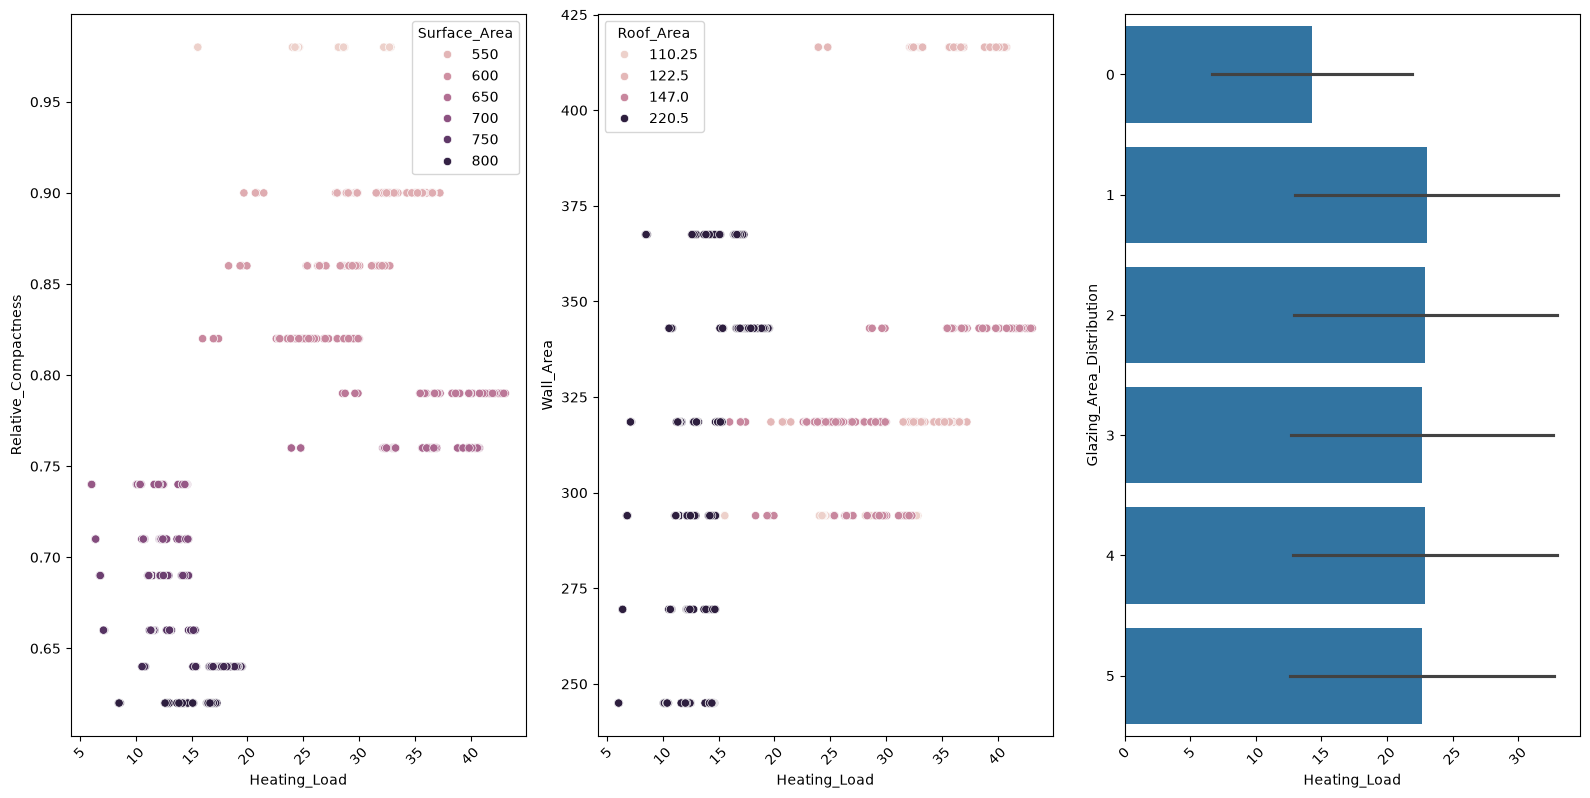

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(16, 8))

sns.scatterplot(
    x='Heating_Load',
    y='Relative_Compactness',
    hue='Surface_Area',
    data=data,
    ax=ax[0]
)

sns.scatterplot(
    x='Heating_Load',
    y='Wall_Area',
    hue='Roof_Area',
    data=data,
    ax=ax[1]
)

sns.barplot(
    x='Heating_Load',
    y='Glazing_Area_Distribution',
    data=data,
    orient='h',
    errorbar='sd',
    ax=ax[2]
)

fig.tight_layout()

for a in ax:
    a.set_xticklabels(a.get_xticklabels(), rotation=45)

## Question 2 (4 points)

Perform linear regression using all the input variables on this dataset to predict the heating load. Carefully evaluate your regression model using appropriate metrics and datasets.


In [5]:
np.random.seed(1)  # For reproducibility

inputs = data.drop('Heating_Load', axis=1)
outputs = data['Heating_Load']

x_train, x_test, y_train, y_test = train_test_split(
    inputs,
    outputs,
    test_size=0.1,
    random_state=1,
)

regressor = LinearRegression()
regressor.fit(
    X=x_train,
    y=y_train,
)
y_hat_train = regressor.predict(x_train)
y_hat_test = regressor.predict(x_test)

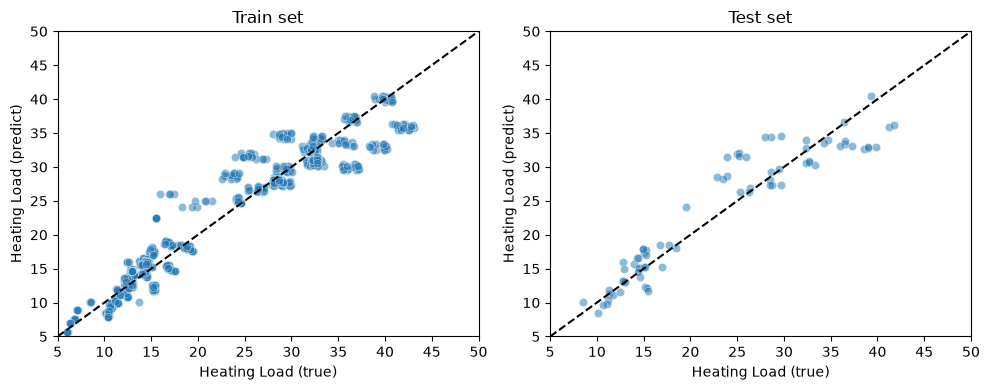

In [6]:
def plot_scatter(y_train, y_hat_train, y_test, y_hat_test):

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    sns.scatterplot(
        x=y_train,
        y=y_hat_train,
        ax=ax[0],
        alpha=0.5,
    )

    sns.scatterplot(
        x=y_test,
        y=y_hat_test,
        ax=ax[1],
        alpha=0.5,
    )

    for a in ax:
        a.set_xlabel('Heating Load (true)')
        a.set_ylabel('Heating Load (predict)')
        a.set_xlim(5, 50)
        a.set_ylim(5, 50)
        a.plot(a.get_xlim(), a.get_ylim(), ls='--', c='k')


        
    ax[0].set_title('Train set')
    ax[1].set_title('Test set')

    fig.tight_layout()

plot_scatter(y_train, y_hat_train, y_test, y_hat_test)

In [7]:
def evaluate_model(y_true, y_pred):
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    scale = np.sqrt(np.mean(y_true**2))
    rmse_scaled = rmse/scale

    return r2, rmse, rmse_scaled

r2_train, rmse_train, rmse_scaled_train = evaluate_model(y_train, y_hat_train)
r2_test, rmse_test, rmse_scaled_test = evaluate_model(y_test, y_hat_test)

print(
    f'{'R2':<15} {r2_train:>10.4f} (train) {r2_test:>10.4f} (test)'
)
print(
    f'{'RMSE':<15} {rmse_train:>10.4f} (train) {rmse_test:>10.4f} (test)'
)
print(
    f'{'RMSE_scaled':<15} {rmse_scaled_train:>10.4f} (train) {rmse_scaled_test:>10.4f} (test)'
)

R2                  0.9191 (train)     0.8867 (test)
RMSE                2.8779 (train)     3.2773 (test)
RMSE_scaled         0.1179 (train)     0.1309 (test)


## Question 3 (4 points)

Now, instead of linear regression, apply kernel ridge regression (documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.kernel_ridge.KernelRidge.html)) with 3 kernels:
1. Linear kernel
2. Polynomial kernel with degree 3
3. RBF (Gaussian) kernel

Quantify the performance improvement (if any) with respect to the linear case, and also the other kernels. What do you observe? Which would you choose?

*Hint: For the RBF kernel, should you do something to the inputs first? Why?*

---

Note: we have not gone through cross validation and hyper-parameter tuning yet, so you are not expected to do this here -- although you are free to do it if you know how.


Answer:

The RBF kernel is based on the distance between two observations. Therefore, the variable that has a larger range will determine the Euclidean distance, even if it is not intrinsically significant. Thus, we could apply `StandardScaler` to transform each feature to comparable scales. I have used the transformed data for all the models below.

In [8]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

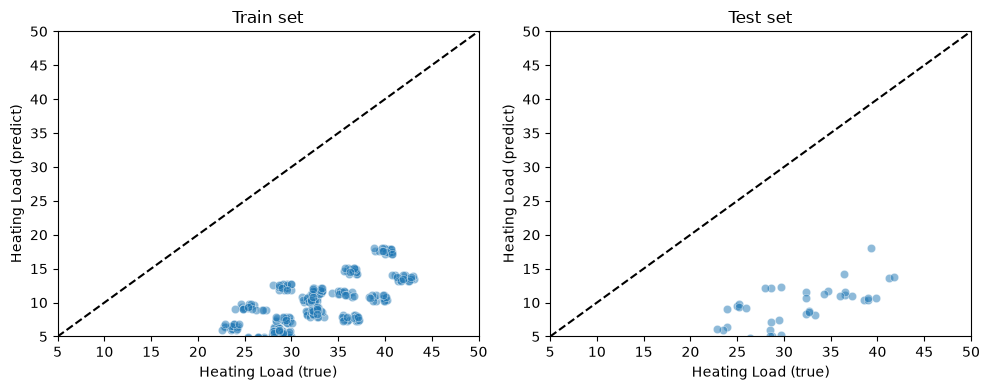

In [9]:
# Linear kernel
kr1 = KernelRidge(
    kernel="linear"
)

kr1.fit(x_train_scaled, y_train)
kr1_train_pred = kr1.predict(x_train_scaled)
kr1_test_pred = kr1.predict(x_test_scaled)

plot_scatter(y_train, kr1_train_pred, y_test, kr1_test_pred)

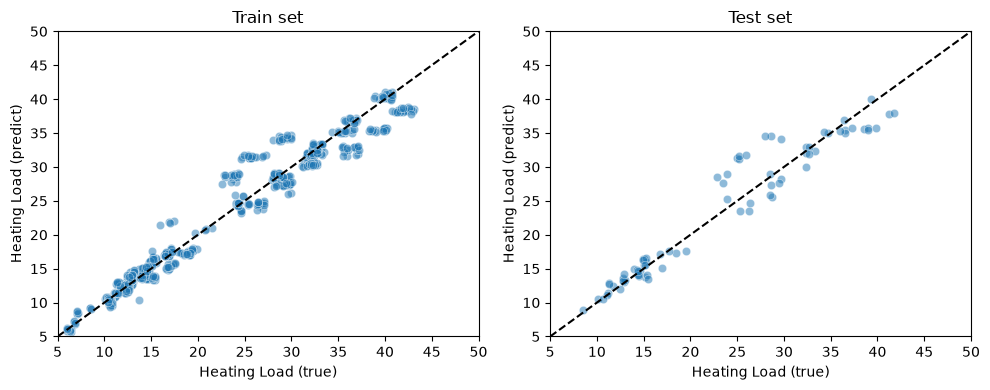

In [10]:
# Polynomial kernel with degree 3
kr2 = KernelRidge(
    kernel="polynomial",
    degree=3
)

kr2.fit(x_train_scaled, y_train)
kr2_train_pred = kr2.predict(x_train_scaled)
kr2_test_pred = kr2.predict(x_test_scaled)

plot_scatter(y_train, kr2_train_pred, y_test, kr2_test_pred)

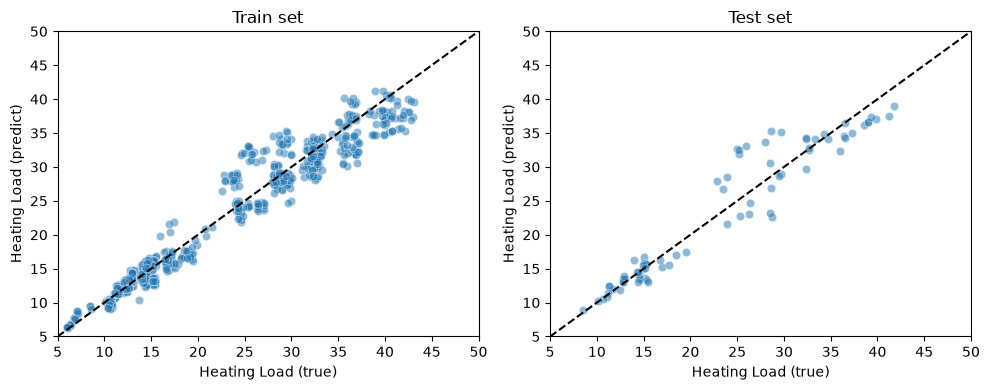

In [11]:
# RBF kernel
kr3 = KernelRidge(
    kernel="rbf"
)

kr3.fit(x_train_scaled, y_train)
kr3_train_pred = kr3.predict(x_train_scaled)
kr3_test_pred = kr3.predict(x_test_scaled)

plot_scatter(y_train, kr3_train_pred, y_test, kr3_test_pred)

In [12]:
# Test performance evaluation
results = []

for name, pred in [
    ("Linear", kr1_test_pred),
    ("Polynomial degree 3", kr2_test_pred),
    ("RBF", kr3_test_pred)
]:
    r2, rmse, rmse_scaled = evaluate_model(y_test, pred)

    results.append({
        "Kernel": name,
        "R2": r2,
        "RMSE": rmse,
        "RMSE_scaled": rmse_scaled
    })

results = pd.DataFrame(results)

linear_rmse = results.loc[
    results["Kernel"] == "Linear", "RMSE"
].iloc[0]

results["RMSE Improvement vs Linear (%)"] = (
    (linear_rmse - results["RMSE"]) / linear_rmse * 100
)

print(results)

                Kernel        R2       RMSE  RMSE_scaled  \
0               Linear -4.177513  22.157564     0.884679   
1  Polynomial degree 3  0.932634   2.527437     0.100912   
2                  RBF  0.916362   2.816199     0.112442   

   RMSE Improvement vs Linear (%)  
0                        0.000000  
1                       88.593345  
2                       87.290122  


Answer:

From the scatter plots and the result table above, it is indicated that both non-linear kernels dramatically outperform the linear kernel. Among them, the polynomial kernel with degree 3 performs the best.